
<h3 align="center">SA4110 MACHINE LEARNING APPLICATION DEVELOPMENT</h3>
<h4 align="center">CA - TEAM PROJECT - IMAGE CLASSIFIER</h4>
<hr>

<div class="alert alert-block alert-info">
<b><u>Tasks:</u></b> 
<ol>
<li>Create an Image Classifier (CNN model) to classify images of fruits correctly.</li>
<li>A Fruits Dataset is provided that consists of these 3 Classes: -</li>
    <ul>
    <li>Apple</li>
    <li>Banana</li>
    <li>Orange</li>
    </ul>
<li>Use the Images in train.zip and test.zip to Train and Test your Image Classifier.</li>
<li>Document your experiments and results in improving your model’s accuracy.</li>
<li>The Following Activities can Improve your Model’s Accuracy: -</li>
    <ul>
    <li>Balance out the Number of Samples in Each Class</li>
    <li>Correct any mis-labelling in any of the 3 Classes</li>
    <li>Image Augmentation to Generate more Data </li>
    </ul>
<li>Use Matplotlib to Generate any Plots that can Help the Reader understand your Work Better.</li>
</ol></div>



In [1]:
### Step 1: Import the Necessary Libraries

# 1. System and OS-level operations
import os
import statistics
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"

# 2. Data Manipulation and Mathematical Operations
import pandas as pd
import numpy as np

# 3. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# 4. Image Processing
from PIL import Image

# 5. Deep Learning Frameworks (PyTorch & Keras)
import torch
import keras
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# 6. Machine Learning Utilities and Metrics (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
### Step 2: Load and Process Image Datasets

def process_image_directory(directory_path, dataset_name="Dataset"):
    """
    Scans a directory for .jpg images, extracts class labels from filenames, 
    calculates median dimensions, and returns a compiled DataFrame.
    """
    print(f"\n--- Processing {dataset_name} ---")
    
    file_names = []
    class_labels = []
    widths = []
    heights = []

    # Single pass through the directory
    for img_path in directory_path.glob("*.jpg"):
        try:
            # 1. Open image to verify it is valid and extract dimensions
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
                
            # 2. Extract metadata ONLY if the image opened successfully
            file_names.append(img_path.name)
            class_labels.append(img_path.name.strip().split('_')[0])
            
        except Exception as e:
            print(f"Unable to read or process {img_path.name}: {e}")

    # Build the DataFrame
    df = pd.DataFrame({
        'fileName': file_names,
        'classLabel': class_labels
    })

    print("-" * 50)
    for i, label in enumerate(df['classLabel'].unique(), start = 1):
        print(f"Class Label {i}: {label}")
    print("-" * 50)

    # Calculate Medians
    median_w, median_h = 0, 0
    if widths and heights:
        median_w = statistics.median(widths)
        median_h = statistics.median(heights)
        print(f"Total Images Evaluated : {len(widths)}")
        print(f"Image Median Width     : {median_w}")
        print(f"Image Median Height    : {median_h}")
    else:
        print(f"No valid .jpg images found in {directory_path}.")
        
    return df, median_w, median_h

# ---------------------------------------------------------
# Execute the Function for Both Directories
# ---------------------------------------------------------
# Define the Path Directories
base_dir = Path.cwd().parents[1]
img_train_dir = base_dir / "train"
img_test_dir = base_dir / "test"

# Process Training Data
class_train_df, img_T_widths_median, img_T_heights_median = process_image_directory(
    directory_path = img_train_dir, 
    dataset_name = "Training Dataset"
)

# Display a sample of the training dataframe to verify
display(HTML("<h3>Training DataFrame Sample:</h3>"))
display(class_train_df.sample(min(5, len(class_train_df)))
        .style
        .set_properties(**{'text-align': 'center', 'color': 'white'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', '#708090')]},
            {'selector':'th', 'props':[('text-align', 'center')]},
            {'selector':'tr:nth', 'props':[('text-align', 'center')]}
        ]))

# Process Testing Data
class_test_df, img_t_widths_median, img_t_heights_median = process_image_directory(
    directory_path = img_test_dir, 
    dataset_name = "Testing Dataset"
)

# Display a sample of the testing dataframe to verify
display(HTML("<h3>Testing DataFrame Sample:</h3>"))
display(class_test_df.sample(min(5, len(class_test_df)))
        .style
        .set_properties(**{'text-align': 'center', 'color': 'white'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', '#708090')]},
            {'selector':'th', 'props':[('text-align', 'center')]},
            {'selector':'tr:nth', 'props':[('text-align', 'center')]}
        ]))


--- Processing Training Dataset ---
--------------------------------------------------
Class Label 1: apple
Class Label 2: banana
Class Label 3: orange
--------------------------------------------------
Total Images Evaluated : 220
Image Median Width     : 640.0
Image Median Height    : 481.5


,fileName,classLabel
176,orange_35.jpg,orange
147,banana_9.jpg,banana
109,banana_43.jpg,banana
92,banana_28.jpg,banana
9,apple_18.jpg,apple



--- Processing Testing Dataset ---
--------------------------------------------------
Class Label 1: apple
Class Label 2: banana
Class Label 3: orange
--------------------------------------------------
Total Images Evaluated : 55
Image Median Width     : 650
Image Median Height    : 500


,fileName,classLabel
17,apple_94.jpg,apple
46,orange_86.jpg,orange
51,orange_92.jpg,orange
10,apple_87.jpg,apple
25,banana_83.jpg,banana


In [3]:
### Step 3: Define a New Class: FruitLabeller

class FruitLabeller(Dataset):
    def __init__(self, class_dataframe, img_directory, transforms = None):
        self.dataframe = class_dataframe
        self.directory = img_directory
        self.transforms = transforms

        unique_labels = sorted(class_dataframe['classLabel'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['fileName']
        img_path = self.directory / img_name
        image = Image.open(img_path).convert("RGB")

        label_str = self.dataframe.iloc[idx]['classLabel']
        label = self.label_map[label_str]

        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
def display_dataset_shape(df, dataset_name):
    shape_df = df['classLabel'].value_counts().sort_index().reset_index()
    shape_df.columns = ['Class Label', 'Total Image']

    display(HTML(f"<h3>{dataset_name} Dataset Shape:</h3>"))
    display(shape_df.style
            .set_properties(**{'color':'white', 'text-align':'center'})
            .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', '#708090')]},
            {'selector':'th', 'props':[('text-align', 'center')]},
            ])
            .hide(axis="index")
            )

In [4]:
### Step 4: Loading the Image Data in PyTorch

# Set Target Size (Max 224x224)
target_width = int(img_T_widths_median) if img_T_widths_median < 224 else 224
target_height = int(img_T_heights_median) if img_T_heights_median < 224 else 224

# Split Data (80% Train, 20% Val)
train_df, val_df = train_test_split(
    class_train_df,
    test_size=0.2,
    random_state=42,
    stratify=class_train_df['classLabel']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Define PyTorch Transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=60),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomCrop((target_height, target_width)),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((target_height, target_width)),
    transforms.ToTensor()
])

# Instantiate PyTorch Datasets
train_dataset = FruitLabeller(train_df, img_train_dir, train_transforms)
val_dataset = FruitLabeller(val_df, img_train_dir, test_transforms)
test_dataset = FruitLabeller(class_test_df, img_test_dir, test_transforms)

# Create PyTorch DataLoaders
train_loader = DataLoader(train_dataset, batch_size=9, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=9, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=9, shuffle=False)

# Display Dataset Shapes
display_dataset_shape(train_df, "Training (80%)")
display_dataset_shape(val_df, "Validation (20%)")
display_dataset_shape(class_test_df, "Testing")

Class Label,Total Image
apple,60
banana,58
orange,58


Class Label,Total Image
apple,15
banana,15
orange,14


Class Label,Total Image
apple,19
banana,18
orange,18


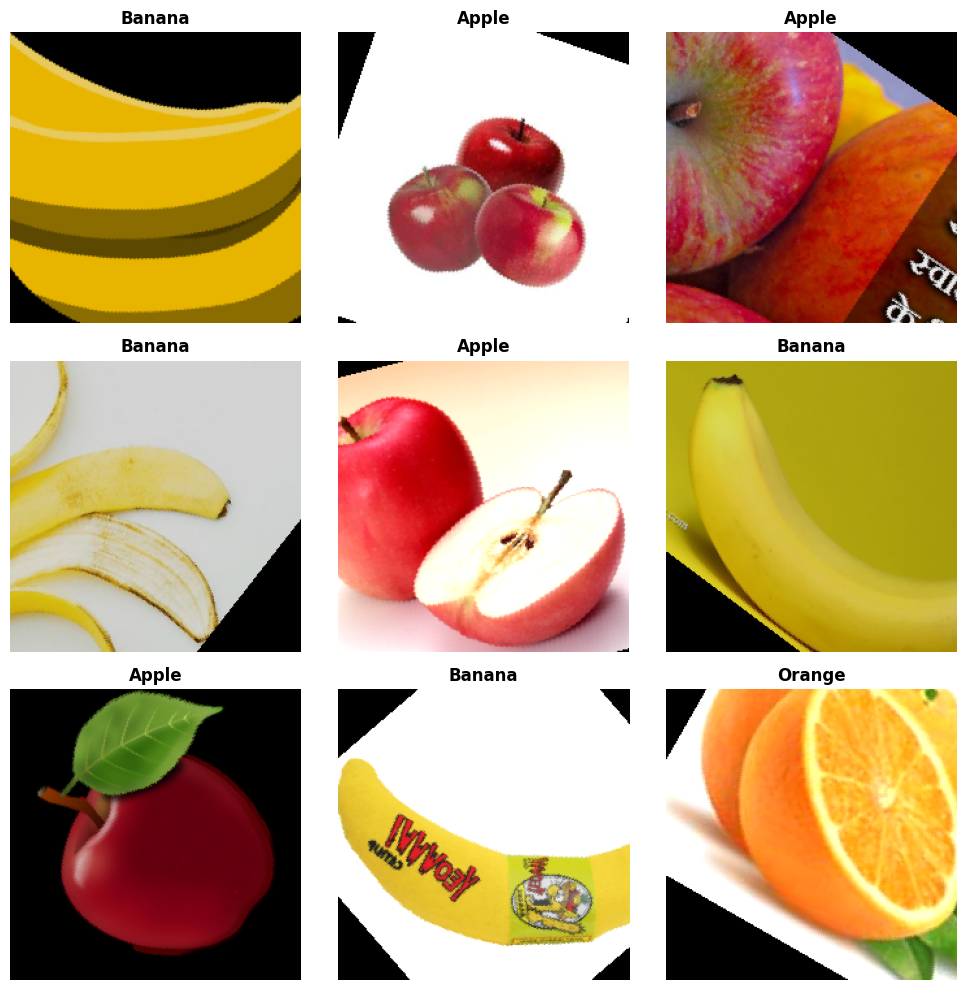

In [5]:
### Step 5: Display Sample Images

images, labels = next(iter(train_loader))
class_names = {v: k for k, v in train_dataset.label_map.items()}

# Set up a 5 x 5 MatPlotLib Grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    img = np.transpose(images[i].numpy(), (1, 2, 0))
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    # Look up the Integer Label in the Dictionary and Set it as the Title
    label_idx = labels[i].item()
    ax.set_title(class_names[label_idx].capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
### Step 6: Establishing the CNN Architecture
# Input Layer   -> (224 x 224 x 3)

model = keras.Sequential([
    keras.layers.Input(shape=(3, 224, 224)),

    # Conv1: 32 filters, Output shape: 224 x 224 x 32
    # PURPOSE: This is the first layer that interacts with the raw image. It scans the 
    # image using a sliding window (kernel) to detect basic, low-level spatial features 
    # like edges, simple textures, and color gradients.
    keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        data_format="channels_first"
    ),

    # MaxPool: 224 x 224 -> 112 x 112
    # PURPOSE: Downsamples the feature maps produced by the convolutional layer. 
    # It takes the maximum value from a 2 x 2 window, effectively reducing the width and 
    # height of the image data by half. This reduces computational cost, controls overfitting, 
    # and makes the network robust to small shifts or translations in the image.
    keras.layers.MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),

    # Conv2: 64 filters, output shape: 112 x 112 x 64
    # PURPOSE: Takes the pooled feature maps from the previous layer and scans them again.
    # Because it's looking at downsampled data, it can learn higher-level, more complex 
    # and abstract features (like shapes or parts of fruits). We increase the 
    # number of filters (to 64) to capture more complex representations.
    keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        data_format="channels_first"
    ),

    # MaxPool: 112 x 112 -> 56 x 56
    # PURPOSE: Downsamples the feature maps produced by the convolutional layer. 
    # It takes the maximum value from a 2 x 2 window, effectively reducing the width and 
    # height of the image data by half. This reduces computational cost, controls overfitting, 
    # and makes the network robust to small shifts or translations in the image.
    keras.layers.MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
    
    # Conv3: 128 filters, output shape: 56 x 56 x 128
    # PURPOSE: Takes the pooled feature maps from the previous layer and scans them again.
    # Because it's looking at downsampled data, it can learn higher-level, more complex 
    # and abstract features (like shapes or parts of fruits). We increase the 
    # number of filters (to 128) to capture more complex representations.
    keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        data_format="channels_first"
    ),

    # MaxPool: 56 x 56 -> 28 x 28
    # PURPOSE: Downsamples the feature maps produced by the convolutional layer. 
    # It takes the maximum value from a 2 x 2 window, effectively reducing the width and 
    # height of the image data by half. This reduces computational cost, controls overfitting, 
    # and makes the network robust to small shifts or translations in the image.
    keras.layers.MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
    # Flatten: 28 x 28 x 128 = 100,352
    # PURPOSE: Convolutional layers output 3D tensors (height, width, channels). However, 
    # our final classification layers (Dense layers) require 1D arrays. This layer simply 
    # unrolls the 3D data into a flat 1D vector.
    keras.layers.Flatten(),

    # Fully connected layer
    # PURPOSE: Acts as the "brain" of the network. It looks at all the flattened features 
    # extracted by the convolutional layers and learns which combinations of features 
    # correlate with which specific fruit classes.
    keras.layers.Dense(128, activation="relu"),

    # Dropout 
    # PURPOSE: Disables 50% of neurons to prevent memorizing the training data
    keras.layers.Dropout(0.5), 
    
    # Output Layer: 3 nodes (Apples, Bananas, Oranges)
    # PURPOSE: Produces the final prediction. 
    # - activation ('softmax'): Converts the raw output scores into a probability 
    # distribution, where all outputs sum up to 1. The highest probability is the prediction.
    keras.layers.Dense(3, activation='softmax')
])

# Display the network structure and parameter count
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
### Step 7: Compile the Model
# SparseCategoricalCrossentropy is strictly required here since 
# the PyTorch dataset outputs are integer labels (0, 1, 2).

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [8]:
### Step 8: Train the Model
# Proceed with Training the Model
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=20
)

Epoch 1/20
 2/20 ━━━━━━━━━━━━━━━━━━━━ 6s 376ms/step - accuracy: 0.1389 - loss: 1.6567

c:\Users\user\machine-learning-class\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - accuracy: 0.4830 - loss: 1.1569 - val_accuracy: 0.9091 - val_loss: 0.4817
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 636ms/step - accuracy: 0.7898 - loss: 0.5866 - val_accuracy: 0.9318 - val_loss: 0.2474
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 888ms/step - accuracy: 0.8636 - loss: 0.4598 - val_accuracy: 0.9773 - val_loss: 0.1291
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 841ms/step - accuracy: 0.9261 - loss: 0.2481 - val_accuracy: 0.9773 - val_loss: 0.1015
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8977 - loss: 0.2990 - val_accuracy: 0.9091 - val_loss: 0.1473
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9205 - loss: 0.2839 - val_accuracy: 1.0000 - val_loss: 0.0594
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9375 - loss: 0.2017 - val_accuracy: 0.9773 - val_loss: 0.0709
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9318 - loss: 0.2833 - val_accuracy: 0.9545 - val_loss:

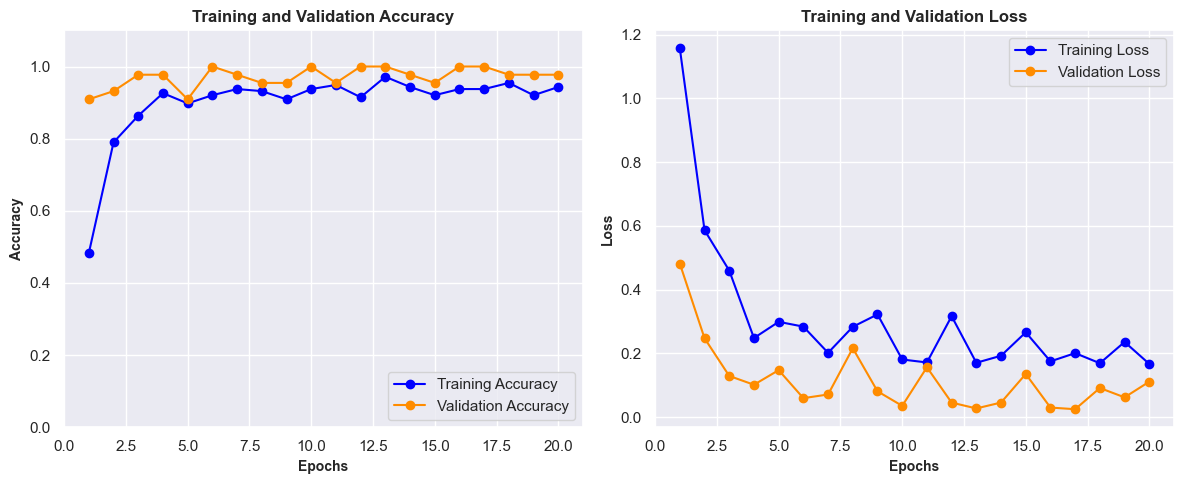

In [9]:
### Step 9: Visualize Training History

# Extract Key Metrics from the History object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

sns.set_theme(style='darkgrid')
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='darkorange')
plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10, fontweight='bold')
plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
plt.legend(loc='lower right')
plt.xlim(0,21)
plt.ylim(0,1.1)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='darkorange')
plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10, fontweight='bold')
plt.ylabel('Loss', fontsize=10, fontweight='bold')
plt.legend(loc='upper right')
plt.xlim(0,21)
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
### Step 10: Evaluate the Model on Test Data
test_loss, test_accuracy = model.evaluate(test_loader)
print(f"{'Final Test Loss':<20} {': '} {test_loss:.4f}")
print(f"{'Final Test Accuracy':<20} {': '} {test_accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.9091 - loss: 0.2607
Final Test Loss      :  0.2607
Final Test Accuracy  :  0.9091



Classification Report
              precision    recall  f1-score   support

       Apple       0.94      0.84      0.89        19
      Banana       0.94      0.89      0.91        18
      Orange       0.86      1.00      0.92        18

    accuracy                           0.91        55
   macro avg       0.91      0.91      0.91        55
weighted avg       0.91      0.91      0.91        55



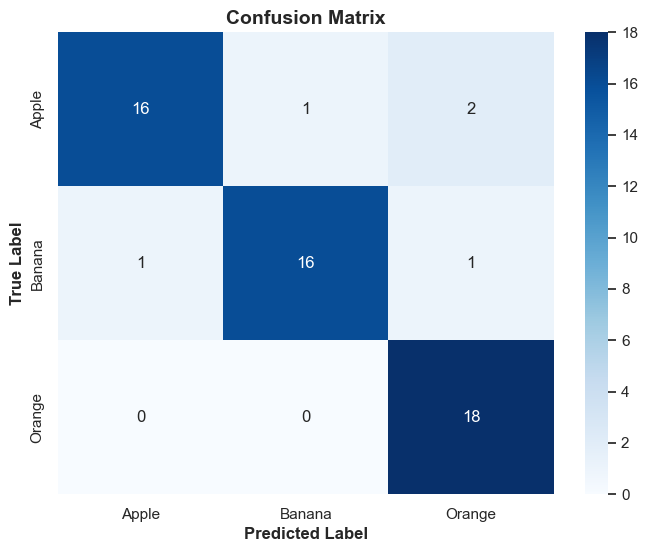

In [11]:
### Step 11: Comprehensive Test Evaluation

# Initialize lists to store true and predicted labels for the entire dataset
all_true_labels = []
all_pred_labels = []

# Iterate through the entire test_loader
for images, labels in test_loader:
    # Get predictions for the current batch (verbose=0 suppresses per-batch output)
    batch_preds_prob = model.predict(images, verbose=0)
    batch_preds = np.argmax(batch_preds_prob, axis=1)
    
    # Append the results to the tracking lists
    all_true_labels.extend(labels.numpy())
    all_pred_labels.extend(batch_preds)

# Generate the Classification Report
# Extract class names in the correct index order
class_names_list = [name.capitalize() for name in train_dataset.label_map.keys()]

print("\n" + "="*50)
print("Classification Report")
print("="*50)
print(classification_report(all_true_labels, all_pred_labels, target_names=class_names_list))

# Generate and Plot the Confusion Matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, 
            yticklabels=class_names_list)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.show()